<a href="https://colab.research.google.com/github/Eshachatterjee01/data_science_all/blob/main/Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Linear Regression based on Insurance Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DataScience_and_MachineLearning_Intellipaat/Datasets/new_insurance_data (1).csv")

In [ ]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [ ]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [ ]:
df.isnull().sum().sum()

np.int64(52)

In [ ]:
columns = list(df.columns)
columns

['age',
 'sex',
 'bmi',
 'children',
 'smoker',
 'Claim_Amount',
 'past_consultations',
 'num_of_steps',
 'Hospital_expenditure',
 'NUmber_of_past_hospitalizations',
 'Anual_Salary',
 'region',
 'charges']

In [ ]:
#you can replace null value by using  col list also not df.columns
#df[i].mode()[0] is used to extract the first (most frequent) value from the list of modes
#so you can plug it into fillna() as a single value
#replacing null value with mode and mean
for i in columns:
  if df[i].dtype == "object":
    df[i] = df[i].fillna(df[i].mode()[0]) #mode()[0]You get a Series of one or more most frequent values (the mode). But fillna() expects a single value.
#So df[i].mode()[0] grabs just the first value — the actual mode — to use for filling.means, in that series there may have 5 yes so it will pich only 0 index yes
  else:
    df[i] = df[i].fillna(df[i].mean())

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df['age'].value_counts()

,count
age,
18.000000,69
19.000000,66
52.000000,29
51.000000,29
47.000000,29
48.000000,29
45.000000,29
46.000000,29
50.000000,29


In [ ]:
df['sex'].value_counts()

,count
sex,
male,676
female,662


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: >

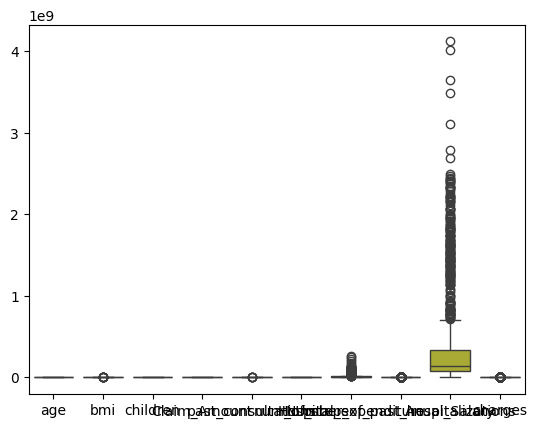

In [ ]:
#outliers
#we cannot understand from this plot
sns.boxplot(df)

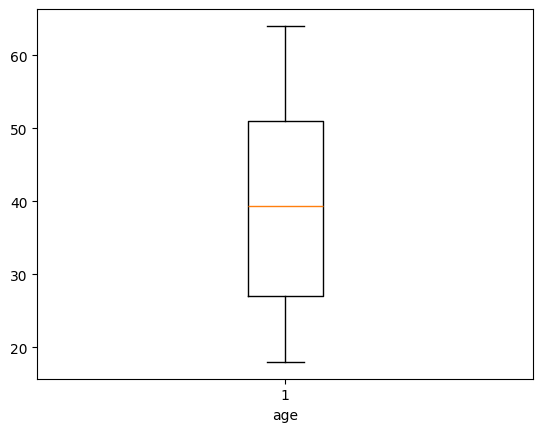

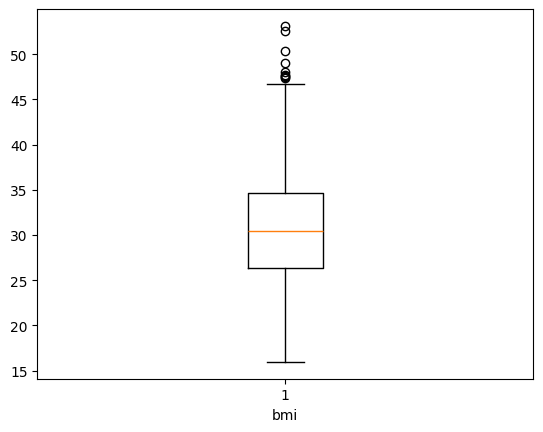

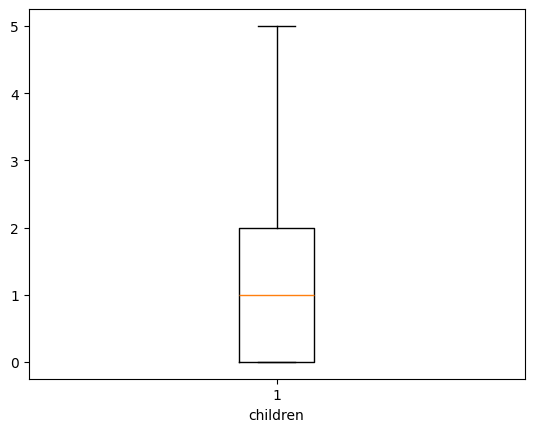

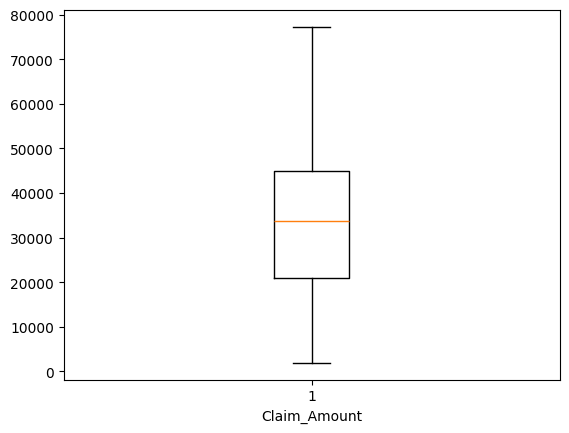

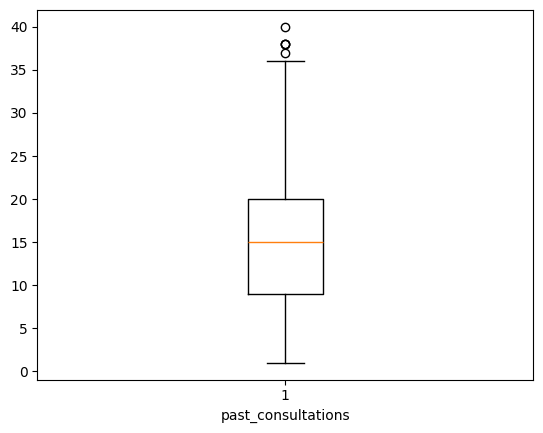

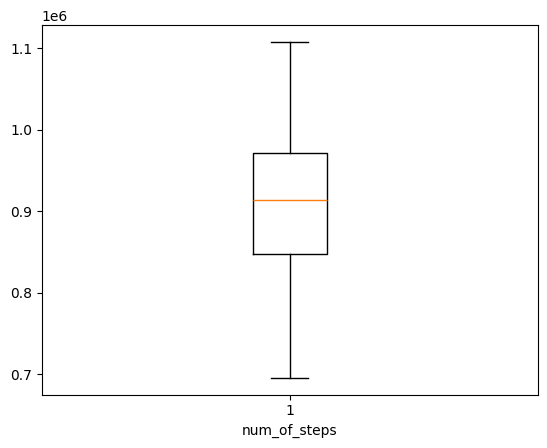

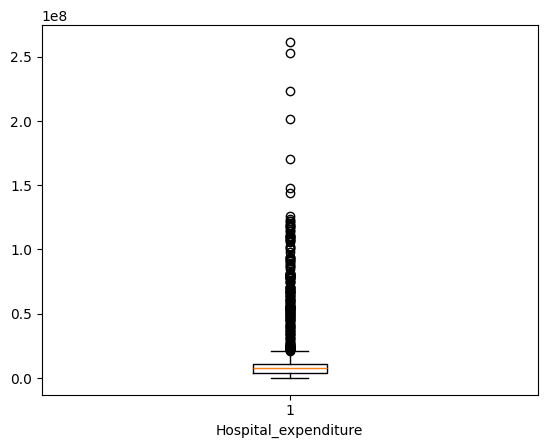

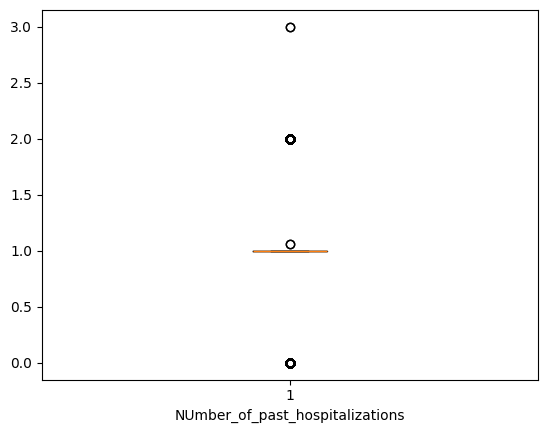

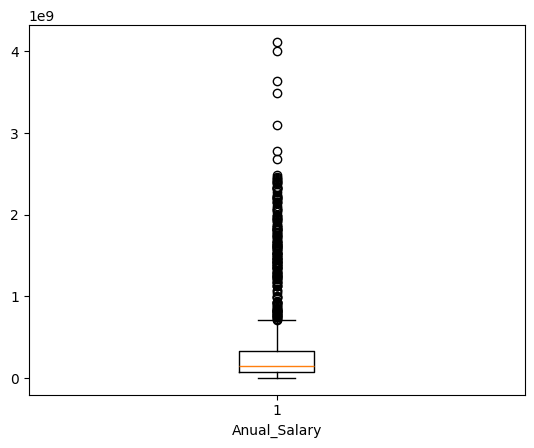

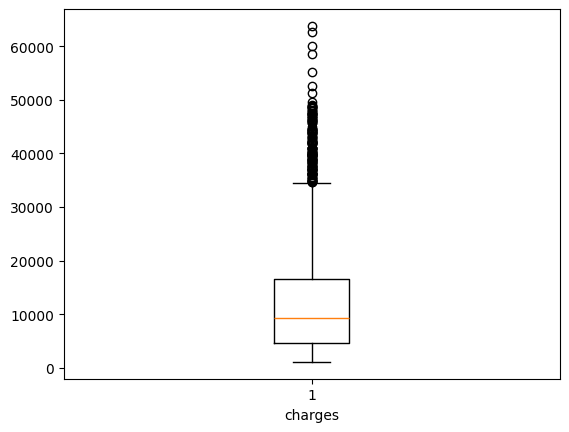

In [ ]:
#we will do for loop to get boxplot for diff column
#i is the column name, not the index.Iterating over a DataFrame by default iterates over columns, not rows.
for i in df.columns:
  if df[i].dtype != "object":
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [ ]:
#which column is target or output column we wont change that column means remove outliers and all
#we will store outliers column in a list
x = ['bmi','past_consultations','Hospital_expenditure','Anual_Salary','NUmber_of_past_hospitalizations']

In [ ]:
#now we will remove the outliers
#lf = lower fence or lower bound or lower unit
#uf = upper fence or upper bound or upper unit
for i in x:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q3 + 1.5*IQR
    df = df[(df[i] >= lower_fence) & (df[i] <= upper_fence)]


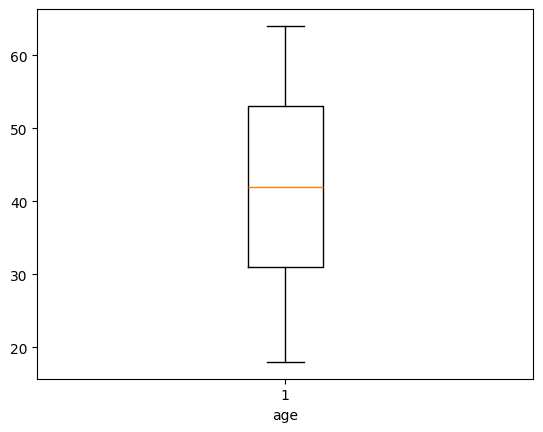

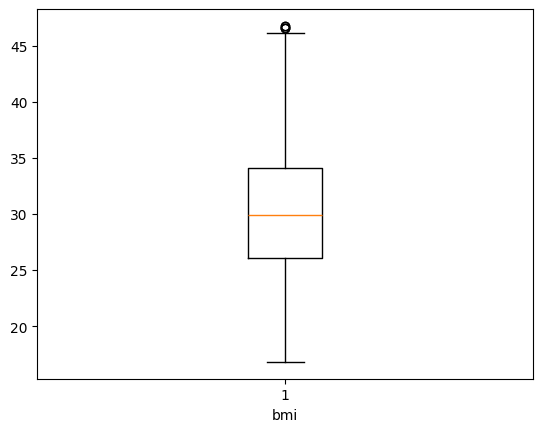

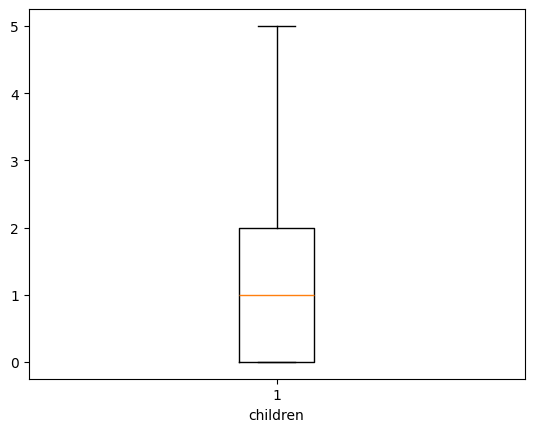

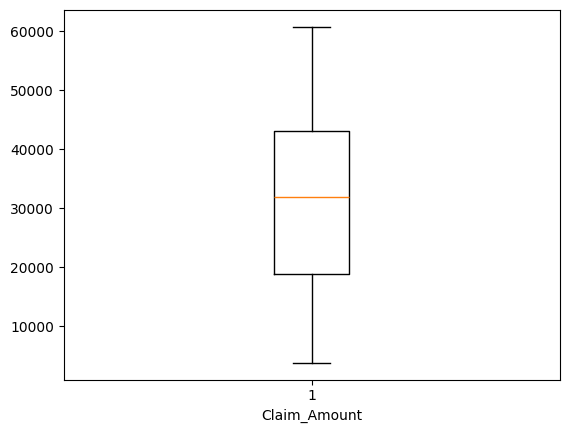

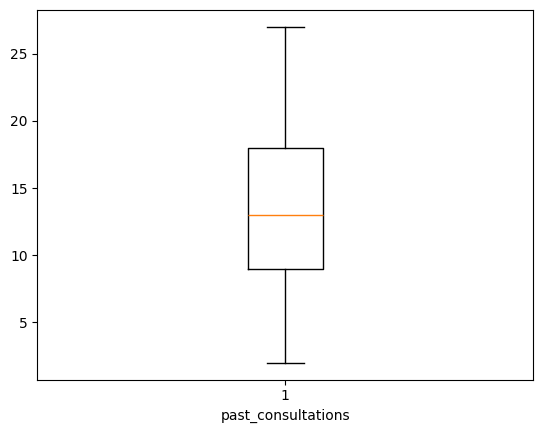

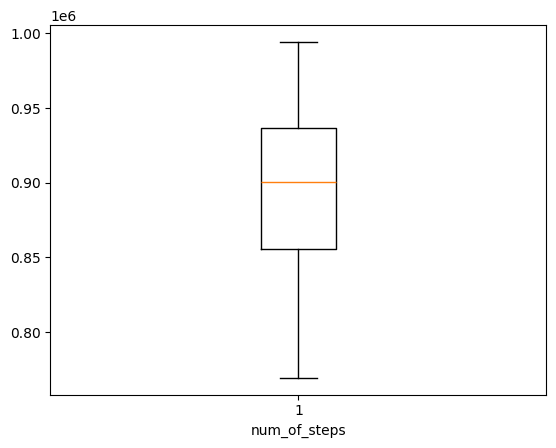

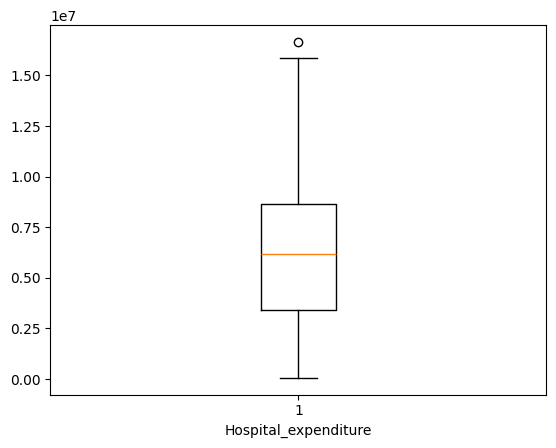

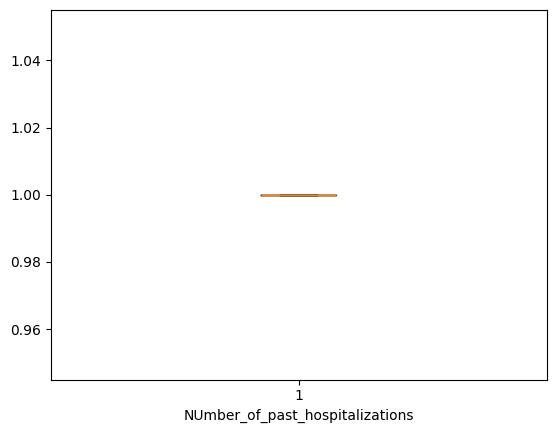

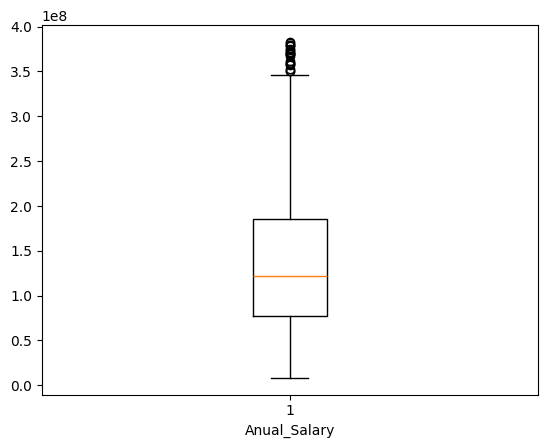

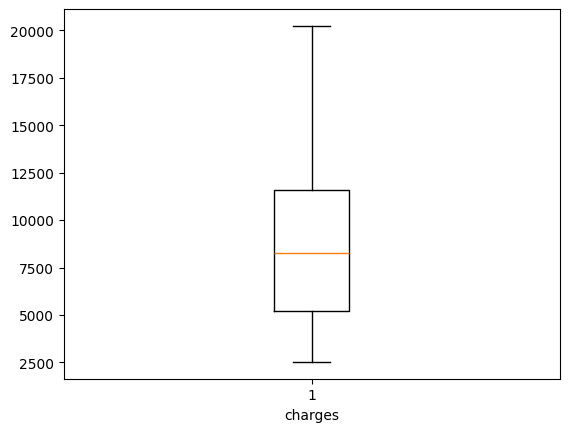

In [ ]:
#now again check the outliers
for i in df.columns:
  if df[i].dtype != "object":
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()


In [ ]:
for i in df.columns:
  print(f"{i} : {df[i].dtype}")


age : float64
sex : object
bmi : float64
children : float64
smoker : object
Claim_Amount : float64
past_consultations : float64
num_of_steps : float64
Hospital_expenditure : float64
NUmber_of_past_hospitalizations : float64
Anual_Salary : float64
region : object
charges : float64


In [ ]:
#now we will do label encoding
#label encoding assign alphabeticaly
#fit use for training.fit will train the model
# transform use for convert object into numeric
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for i in df.columns:
  if df[i].dtype == "object":
    df[i] = le.fit_transform(df[i])

In [ ]:
#now all object converted into numeric datatype
for i in df.columns:
  print(f"{i} : {df[i].dtype}")

age : float64
sex : int64
bmi : float64
children : float64
smoker : int64
Claim_Amount : float64
past_consultations : float64
num_of_steps : float64
Hospital_expenditure : float64
NUmber_of_past_hospitalizations : float64
Anual_Salary : float64
region : int64
charges : float64


In [ ]:
# #import lib
# #split the data
# x- indepen
# y-dep
# traintestsplit
# training
# testing
# # evaluation metrics


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [ ]:
#importing library
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

In [ ]:
#splliting the data
X = df.drop(columns = ['charges']) #independent column
Y = df['charges'] ##dependent column or target column

training x-train y-train  
testing x-test  
--answers from the model ---ypred  
evaluation -y_pred vs y_test  
r2scre

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size= 0.2,random_state=42)

In [ ]:
my_model = LinearRegression()

In [ ]:
my_model.fit(X_train,Y_train)

LinearRegression()

In [ ]:
y_pred = my_model.predict(X_test)

In [ ]:
y_pred

array([ 7607.85080352,  5308.50427948,  9493.31042711, 11142.11548302,
        7177.46290601,  3162.24752057, 10130.3531249 , 13303.16888518,
        8599.14496062, 11971.4971193 , 12391.60209106, 12308.57988734,
        6074.84855493, 15108.92969082, 13528.02651336,  7984.76016645,
        6240.02537329,  7187.31088404,  8075.1834396 , 11911.07958654,
        8019.95879386,  1742.29810803,  7597.0023742 ,  1759.7024501 ,
        6684.04708442, 12676.42553721,  7366.28224082, 14058.52278458,
       11632.69299004,  7014.33187856,  9642.68306372,  3267.35636644,
        7828.96839265,  5055.90862348,  8297.26173924,  5815.33440369,
        2792.33801229, 10373.99286023,  6611.11488772,  2070.84957381,
        5819.98742891,  3574.34526225, 18529.57610284,  8941.22584014,
       11742.74695686,  4900.04298218, 12873.02532985,  7772.21386862,
        2975.38519267, 11871.09823443,  6261.18825847, 15106.80220452,
        9937.02441202,  4358.21273492, 15180.54205106,  7542.51468189,
      

In [ ]:
Y_test

,charges
501,6986.6970
405,5615.3690
642,8944.1151
843,11945.1327
544,7512.2670
...,...
549,7624.6300
938,13831.1152
559,7731.4271
503,7046.7222


In [ ]:
#compare actual Y_test with Predicted Y_test(y_pred)
#now it is not in proper dataframe ..if we will put into dataframe then we can compare y_pred value with y_test value

result = pd.DataFrame(columns = ['Actual_Data_Y_test','Predicted_Data_Y_pred'])
result



,Actual_Data_Y_test,Predicted_Data_Y_pred


In [ ]:
result['Actual_Data_Y_test'] = Y_test
result['Predicted_Data_Y_pred'] = y_pred

In [ ]:
#compare what was actual and what is predicted value
result

,Actual_Data_Y_test,Predicted_Data_Y_pred
501,6986.6970,7607.850804
405,5615.3690,5308.504279
642,8944.1151,9493.310427
843,11945.1327,11142.115483
544,7512.2670,7177.462906
...,...,...
549,7624.6300,6716.507771
938,13831.1152,13773.884109
559,7731.4271,7077.850524
503,7046.7222,7968.328787


In [ ]:
r2_score(Y_test,y_pred)

0.9689411111502325

In [ ]:
mean_squared_error(Y_test,y_pred)

537564.6928342418

In [ ]:
mean_absolute_error(Y_test,y_pred)

590.981954774146

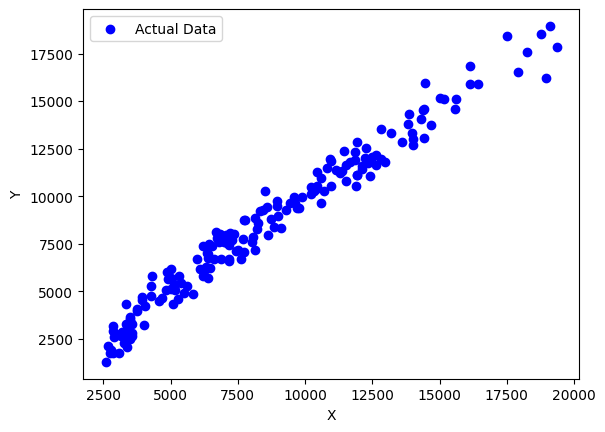

In [ ]:
#visualization
plt.scatter(Y_test,y_pred,color = 'blue', label = 'Actual Data')
plt.plot(linewidth = 2)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [ ]:
df.shape

(881, 13)

In [ ]:
my_model.fit(X_train,Y_train)

LinearRegression()

In [ ]:
#check overfit or not
x_train_predict = my_model.predict(X_train)
x_test_predict = my_model.predict(X_test)

In [ ]:
r2_score(x_train_predict,Y_train)

0.9630016864342411

In [ ]:
r2_score(x_test_predict,Y_test)

0.9679020834725249

## Linear Regression on Boston Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DataScience_and_MachineLearning_Intellipaat/Datasets/Boston (1).csv')

In [ ]:
data

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
data.shape

(506, 14)

In [ ]:
data.isnull().sum().sum()

np.int64(0)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
#check datatype
for i in data.columns:
    print(f"{i} : {data[i].dtype}")


crim : float64
zn : float64
indus : float64
chas : int64
nox : float64
rm : float64
age : float64
dis : float64
rad : int64
tax : int64
ptratio : float64
black : float64
lstat : float64
medv : float64


In [ ]:
data.dtypes

,0
crim,float64
zn,float64
indus,float64
chas,int64
nox,float64
rm,float64
age,float64
dis,float64
rad,int64
tax,int64


In [ ]:
#detect outlier
for i in df.columns:
  if df[i].dtype != "object":
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [ ]:
for i in x:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q3 + 1.5*IQR
    df = df[(df[i] >= lower_fence) & (df[i] <= upper_fence)]

In [ ]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')

In [ ]:
x = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax','ptratio', 'black', 'lstat']
for i in x:
  Q1 = data[i].quantile(0.25)
  Q3 = data[i].quantile(0.75)
  IQR = Q3 - Q1
  lower_fence = Q1- IQR*1.5
  upper_fence = Q3 + 1.5*IQR
  data = data[(data[i] >= lower_fence ) & (data[i] <= upper_fence)]

In [ ]:
#so dont do outlier remove because dataset is very small
data.shape

(0, 14)

We will perform these following steps in data exploration:  
Null values  
Duplicates  
Data types of the values in each column.  
Outliers present in the data.  
Necessary Visualizations.  

# Machine Learning Process¶

#### steps to perform in machine learning process

1. Creating X and y variables.
2. Splitting the given dataset into training and testing data.
3. Standardization/Scaling of the data.
4. Applying the algorithm on the data which is also known as training of the ml model.
5. Check the performance of the model on the testing data.

In [ ]:
X = data.drop(columns = ['medv'])
Y = data['medv']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=52)

In [ ]:
#we will do standardization
from sklearn.preprocessing import StandardScaler

se = StandardScaler()
x_train = se.fit_transform(x_train)
x_test = se.transform(x_test)

In [ ]:
my_model = LinearRegression()
my_model.fit(x_train,y_train)

LinearRegression()

In [ ]:
my_model.intercept_

np.float64(22.466584158415845)

In [ ]:
my_model.coef_

array([-5.01089349e-01,  1.01910345e+00,  4.02209264e-01,  2.45858216e-01,
       -1.88648673e+00,  2.82543717e+00,  2.48751939e-03, -2.99899146e+00,
        2.53723763e+00, -2.38453814e+00, -2.14785884e+00,  1.01457079e+00,
       -3.62846152e+00])

In [ ]:
y_pred = my_model.predict(x_test)

In [ ]:
r2_score(y_test,y_pred)

0.7575780935580403

In [ ]:
#check overfitting
x_train_pred = my_model.predict(x_train)

In [ ]:
r2_score(x_train_pred,y_train)

0.6318124633609744

# **Regularization**

we are taking a dataset which will give best result in training but not in testing means overfitted data .. so we will use regularization to handle model overfit

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:

# Load dataset (diabetes is a common regression dataset)
X, y = load_diabetes(return_X_y=True, as_frame=True)

In [ ]:
X,y

(          age       sex       bmi        bp        s1        s2        s3  \
 0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
 1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
 2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
 3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
 4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
 ..        ...       ...       ...       ...       ...       ...       ...   
 437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
 438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
 439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
 440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
 441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   
 
            s4        s5        s6  
 0   -0.002592  0.019907 

In [ ]:
data = X.copy()
data["target"] = y

In [ ]:
data

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [ ]:
x = data.drop(columns=['target'])
y = data['target']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
# Models
lin_reg = LinearRegression()
ridge = Ridge(alpha=1.0)      # alpha = λ, higher -> stronger regularization
lasso = Lasso(alpha=0.1)      # L1 regularization

In [ ]:
lin_reg.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = lin_reg.predict(X_test)

In [ ]:
r2_score(y_pred,y_test)

0.006904915832163794

Linear Regression -> MSE: 2900.19, R²: 0.45
Ridge Regression -> MSE: 3077.42, R²: 0.42
Lasso Regression -> MSE: 2798.19, R²: 0.47

Coefficients comparison:
    Feature      Linear       Ridge       Lasso
0        0   37.904021   45.367377    0.000000
1        1 -241.964362  -76.666086 -152.664779
2        2  542.428759  291.338832  552.697775
3        3  347.703844  198.995817  303.365158
4        4 -931.488846   -0.530310  -81.365007
5        5  518.062277  -28.577050   -0.000000
6        6  163.419983 -144.511905 -229.255776
7        7  275.317902  119.260066    0.000000
8        8  736.198859  230.221608  447.919525
9        9   48.670657  112.149830   29.642617


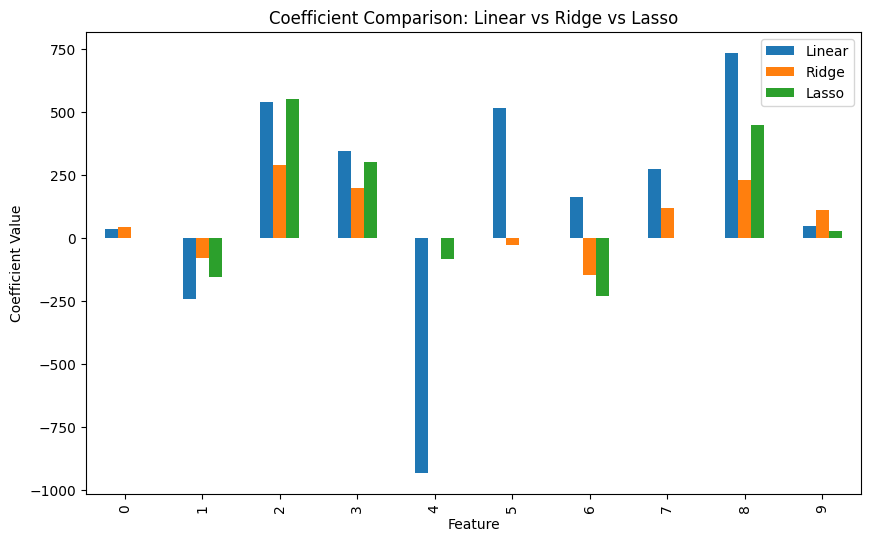

In [ ]:
# Fit models
lin_reg.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Predictions
y_pred_lin = lin_reg.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

# Evaluate
def evaluate(name, y_test, y_pred):
    print(f"{name} -> MSE: {mean_squared_error(y_test, y_pred):.2f}, "
          f"R²: {r2_score(y_test, y_pred):.2f}")

evaluate("Linear Regression", y_test, y_pred_lin)
evaluate("Ridge Regression", y_test, y_pred_ridge)
evaluate("Lasso Regression", y_test, y_pred_lasso)

# Compare coefficients
coef_df = pd.DataFrame({
    "Feature": range(X.shape[1]),
    "Linear": lin_reg.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})
print("\nCoefficients comparison:\n", coef_df)

# Plot coefficients
coef_df.set_index("Feature").plot(kind="bar", figsize=(10,6))
plt.title("Coefficient Comparison: Linear vs Ridge vs Lasso")
plt.ylabel("Coefficient Value")
plt.show()